---
## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## 2. Paramètres physiques et de discrétisation

In [2]:
L     = 1.0    # longueur de la poutre [m]
v     = 1.0    # vitesse des ondes [m/s]

Nx    = 100    # points en espace
Nt    = 3000   # pas de temps internes (fin, pour la stabilité numérique)
t_end = 5.0    # durée de simulation [s]

# On ne garde qu'1 pas de temps sur T_SUB pour alléger le dataset.
# Le Δt_effectif entre deux snapshots sauvegardés = T_SUB * (t_end/Nt)
T_SUB = 3

dt_save = T_SUB * (t_end / Nt)   # Δt entre deux snapshots consécutifs
print(f"Δt entre snapshots sauvegardés : {dt_save:.5f} s")

Δt entre snapshots sauvegardés : 0.00500 s


---
## 3. Espace des paramètres (A, ω)

On fait varier amplitude et pulsation pour que le modèle apprenne à généraliser.
Toutes les valeurs de ω doivent satisfaire $\lambda = 2\pi v / \omega < L$.

In [3]:
N = 5

AMPLITUDES = [0.05]
PULSATIONS = [10]

print(AMPLITUDES)
print(PULSATIONS)
# Vérification : la longueur d'onde doit être < L
omega_min_valid = 2 * np.pi * v / L
print(omega_min_valid)

for w in PULSATIONS:
    assert w > omega_min_valid, f"ω={w} invalide : longueur d'onde trop grande"

n_sims = len(AMPLITUDES) * len(PULSATIONS)
print(f"{len(AMPLITUDES)} amplitudes × {len(PULSATIONS)} pulsations = {n_sims} simulations")

[0.05]
[10]
6.283185307179586
1 amplitudes × 1 pulsations = 1 simulations


---
## 4. Fonction de simulation

In [4]:
def run_simulation(A_force, omega, L=L, v=v, Nx=Nx, Nt=Nt, t_end=t_end, t_sub=T_SUB):
    
    """
    Simule la poutre et retourne un DataFrame.
    Une ligne = un point (x,t) avec son état (u) et ses dérivées locales (u_dot, u_xx).
    """

    # Grille spatiale : Nx points régulièrement espacés entre 0 et L
    x  = np.linspace(0, L, Nx)
    dx = x[1] - x[0]       # distance entre deux points voisins
    dt = t_end / Nt         # durée d'un pas de temps interne

    # Vérification de stabilité numérique :
    # si CFL > 1, le schéma explose (les ondes "sautent" par-dessus des points)
    CFL = v * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable — augmenter Nt"

    # État initial : la poutre est au repos (déplacement nul partout)
    u_prev = np.zeros(Nx)   # déplacement à t-1
    u_curr = np.zeros(Nx)   # déplacement à t

    # -------------------------------------------------------
    # Étape 1 : faire tourner la simulation et sauvegarder 
    # des snapshots complets tous les t_sub pas
    # -------------------------------------------------------
    snapshots_u    = []   # liste des champs u(x) sauvegardés
    snapshots_udot = []   # liste des champs u_dot(x) sauvegardés
    snapshots_uxx  = []
    snapshots_t    = []


    for n in range(1, Nt - 1):
        tn     = n * dt          # temps physique actuel
        u_next = np.empty(Nx)    # tableau pour stocker l'état au pas suivant

        # Équation des ondes par différences finies sur les points intérieurs
        # (exclut x=0 et x=L qui sont gérés par les conditions aux limites)
        # Formule : u(t+1) = 2*u(t) - u(t-1) + CFL² * (u_gauche - 2*u + u_droite)
        u_next[1:-1] = (
            2.0 * u_curr[1:-1]
            - u_prev[1:-1]
            + CFL**2 * (u_curr[2:] - 2.0*u_curr[1:-1] + u_curr[:-2])
        )

        # Condition aux limites gauche : encastrement → déplacement nul en x=0
        u_next[0]  = 0.0

        # Condition aux limites droite : force sinusoïdale appliquée en x=L
        # On impose la dérivée spatiale : du/dx = A*sin(ω*t)
        # Approximation par différences finies : u[-1] = u[-2] + dx * A*sin(ω*t)
        u_next[-1] = u_next[-2] + dx * A_force * np.sin(omega * tn)

        # Sauvegarde du snapshot tous les t_sub pas de temps
        # (on ne garde pas tout pour alléger le dataset)
        if n % t_sub == 0:
            
            # Vitesse estimée par différence centrée : (u(t+1) - u(t-1)) / (2*dt)
            # Plus précis qu'une différence avant ou arrière
            u_dot = (u_next - u_prev) / (2 * dt)
            
            u_xx = np.zeros(Nx)
            u_xx[1:-1] = (u_curr[2:] - 2.0*u_curr[1:-1] + u_curr[:-2]) / dx**2
            

            snapshots_u   .append(u_curr.copy())   # on sauvegarde u au temps t
            snapshots_udot.append(u_dot .copy())   # et sa vitesse estimée
            snapshots_uxx.append(u_xx.copy())
            snapshots_t   .append((n) * dt)     #time t

        # Décalage : le "présent" devient le "passé" pour le prochain pas
        u_prev = u_curr
        u_curr = u_next

    # -------------------------------------------------------
    # Étape 2 : construire les lignes du dataset à partir des snapshots
    # Chaque transition = paire (snapshot i, snapshot i+1)
    # C'est une ligne du dataset d'entraînement
    # -------------------------------------------------------
    rows = []
    for i in range(len(snapshots_u)-1):

        u_field    = snapshots_u   [i]
        udot_field = snapshots_udot[i]
        uxx_field  = snapshots_uxx [i]
        t_snap     = snapshots_t   [i]
        delta_u_field = snapshots_u[i+1]-u_field

        y     = 0.5 * (u_field[0::2] + u_field[1::2])      # taille Nx/2 = 50
        y_dot = 0.5 * (udot_field[0::2] + udot_field[1::2])
        
        for k in range (Nx//2):
            d_left  = u_field[2*k]   - y[k]   # = -(u[2k+1] - u[2k]) / 2
            d_right = u_field[2*k+1] - y[k]   # = +(u[2k+1] - u[2k]) / 2    

        y_xx = np.zeros_like(y)
        y_xx[1:-1] = (y[2:] - 2*y[1:-1] + y[:-2]) / (2*dx)**2  # pas spatial = 2*dx
        
        delta_y    = dt_save * y_dot + 0.5 * dt_save**2 * v**2 * y_xx       #Taylor for the y vectors

        yL = delta_y[0::2]   # delta_y au midpoint gauche de chaque groupe
        yR = delta_y[1::2]  
        
        # Distances : ici uniformes, mais on les nomme pour que le moment soit lisible
        d1 = dx/2          # x1 ← y1 (à gauche de y1)
        d2 = dx/2          # y1 → x2
        d3 = dx/2          # x3 ← y2
        d4 = dx/2          # y2 → x4
        D  = d2 + dx + d3  # = 2*dx, distance entre ancres y1 et y2
        
        # Poids "moment des leviers" sur (y1, y2) pour chaque position fine
        w_x1 = ((D + d1) / D, -d1 / D)        # = ( 5/4, -1/4)
        w_x2 = ((D - d2) / D,  d2 / D)        # = ( 3/4,  1/4)
        w_x3 = ( d3 / D, (D - d3) / D)        # = ( 1/4,  3/4)
        w_x4 = (-d4 / D, (D + d4) / D)        # = (-1/4,  5/4)

        delta_u_coarse_field = np.empty(Nx)
        delta_u_coarse_field[0::4] = w_x1[0]*yL + w_x1[1]*yR
        delta_u_coarse_field[1::4] = w_x2[0]*yL + w_x2[1]*yR
        delta_u_coarse_field[2::4] = w_x3[0]*yL + w_x3[1]*yR
        delta_u_coarse_field[3::4] = w_x4[0]*yL + w_x4[1]*yR

        # Pour chaque nœud intérieur (on exclut les bords x=0 et x=L
        # car leurs valeurs sont imposées par les conditions aux limites)
        for j in range(1, Nx - 1):
            rows.append({
                # --- Inputs : état physique au temps t ---
                "u"          : u_field[j],      # déplacement en ce point
                "x"          : x[j],        # position du nœud sur la poutre
                "A"          : A_force,     # amplitude de la force (paramètre global)
                "omega"      : omega,       # pulsation de la force (paramètre global)
                "t"          : t_snap,
                "sin_wt"     : np.sin(omega * t_snap),
                "cos_wt"     : np.cos(omega * t_snap),

                # --- Outputs : changements sur Δt ---
                "u_dot":udot_field[j],
                "u_xx":uxx_field[j],
                "delta_u":delta_u_field[j],
                "delta_u_coarse": delta_u_coarse_field[j],
            })

    return pd.DataFrame(rows)



---
## 5. Génération du dataset complet

In [5]:
all_dfs = []

#We compute each simulation
for idx, (A, w) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    df_run = run_simulation(A_force=A, omega=w)
    all_dfs.append(df_run)

#We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)

err = df["delta_u"] - df["delta_u_coarse"]

# Optionnel : tracé
import matplotlib.pyplot as plt
lim = max(df["delta_u"].abs().max(), df["delta_u_coarse"].abs().max())


---
## 7. Split train / val / test

**Note (cas réduit)** : ici on n'a qu'**une seule** simulation (1 amplitude × 1 pulsation),
donc on ne peut pas splitter par combinaison (A, ω) comme dans la version complète.
On fait à la place un split **par ligne** (random shuffle 70/15/15).

In [6]:
rng = np.random.default_rng(seed=42)

if n_sims >= 4:
    # --- Split par combinaison (A, ω) — version complète ---
    combos     = list(product(AMPLITUDES, PULSATIONS))
    combos_arr = rng.permutation(combos)

    n_train = int(0.70 * n_sims)
    n_val   = int(0.15 * n_sims)

    train_combos = set(map(tuple, combos_arr[:n_train]))
    val_combos   = set(map(tuple, combos_arr[n_train:n_train + n_val]))
    test_combos  = set(map(tuple, combos_arr[n_train + n_val:]))

    def assign_split(row):
        key = (row["A"], row["omega"])
        if key in train_combos: return "train"
        if key in val_combos:   return "val"
        return "test"

    df["split"] = df.apply(assign_split, axis=1)

else:
    # --- Split par ligne (cas réduit, n_sims trop petit) ---
    n_rows  = len(df)
    perm    = rng.permutation(n_rows)
    n_train = int(0.70 * n_rows)
    n_val   = int(0.15 * n_rows)

    splits = np.empty(n_rows, dtype=object)
    splits[perm[:n_train]]                 = "train"
    splits[perm[n_train:n_train + n_val]]  = "val"
    splits[perm[n_train + n_val:]]         = "test"
    df["split"] = splits

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")


Distribution du split :
  train :   68,462 lignes  (70.0 %)
  val   :   14,670 lignes  (15.0 %)
  test  :   14,672 lignes  (15.0 %)


---
## 8. Normalisation (z-score)

**Règle importante** : les statistiques (moyenne, écart-type) sont calculées
**uniquement sur le train set**, puis appliquées à val et test.
Si on calculait sur tout le dataset, on introduirait une fuite d'information.

On sauvegarde ces statistiques dans un fichier séparé — elles seront
nécessaires dans les fichiers d'entraînement et de validation.

In [7]:
INPUTS  = ["u", "t", "x", "A", "omega", "sin_wt", "cos_wt"]
OUTPUTS = ["u_dot", "u_xx", "delta_u"]

train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))


Statistiques de normalisation (calculées sur train) :
              mean       std
u         0.000553  0.005448
t         2.505131  1.441452
x         0.501348  0.285364
A         0.050000  0.000000
omega    10.000000  1.000000
sin_wt   -0.000434  0.708336
cos_wt   -0.005560  0.705864
u_dot     0.000994  0.042617
u_xx     -0.003287  0.435077
delta_u   0.000005  0.000213


---
## 9. Sauvegarde

In [8]:
COLS_ORDER = ["x", "t", "u", "delta_u","delta_u_coarse"]
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  97,804 lignes × 5 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [9]:
import json

params_simulation = {
    "L"          : L,
    "v"          : v,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "T_SUB"      : T_SUB,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


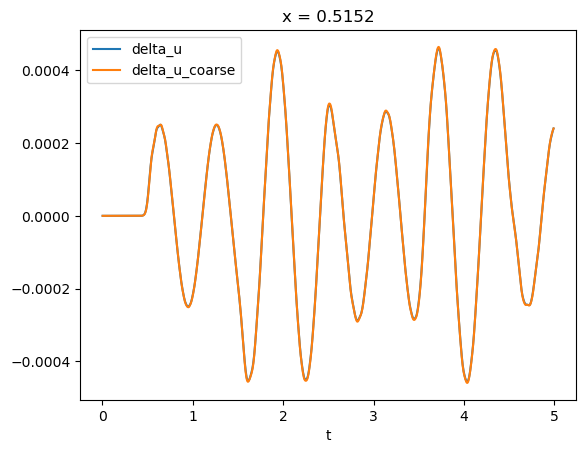

In [10]:

df = pd.read_csv("wave_beam_dataset.csv")

# Choisis un x
x_val = df["x"].unique()[50]  # change l'index pour un autre point
subset = df[df["x"] == x_val].sort_values("t")

plt.plot(subset["t"], subset["delta_u"], label="delta_u")
plt.plot(subset["t"], subset["delta_u_coarse"], label="delta_u_coarse")
plt.xlabel("t")
plt.title(f"x = {x_val:.4f}")
plt.legend()
plt.show()

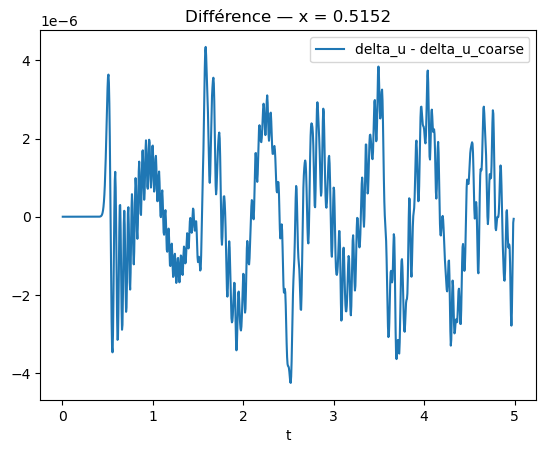

In [11]:
subset["diff"] = subset["delta_u"] - subset["delta_u_coarse"]
plt.plot(subset["t"], subset["diff"], label="delta_u - delta_u_coarse")
plt.xlabel("t")
plt.title(f"Différence — x = {x_val:.4f}")
plt.legend()
plt.show()